In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("SuperStoreOrders.csv")

In [3]:

print(df.head())


print(df.shape)


print(df.columns)


print(df.dtypes)

          order_id order_date ship_date       ship_mode    customer_name  \
0     AG-2011-2040   1/1/2011  6/1/2011  Standard Class  Toby Braunhardt   
1    IN-2011-47883   1/1/2011  8/1/2011  Standard Class      Joseph Holt   
2     HU-2011-1220   1/1/2011  5/1/2011    Second Class    Annie Thurman   
3  IT-2011-3647632   1/1/2011  5/1/2011    Second Class     Eugene Moren   
4    IN-2011-47883   1/1/2011  8/1/2011  Standard Class      Joseph Holt   

       segment            state    country  market   region  ...  \
0     Consumer      Constantine    Algeria  Africa   Africa  ...   
1     Consumer  New South Wales  Australia    APAC  Oceania  ...   
2     Consumer         Budapest    Hungary    EMEA     EMEA  ...   
3  Home Office        Stockholm     Sweden      EU    North  ...   
4     Consumer  New South Wales  Australia    APAC  Oceania  ...   

          category sub_category                 product_name sales quantity  \
0  Office Supplies      Storage          Tenex Lockers,

In [4]:
print(df.isnull().sum())

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64


In [5]:
df.columns = df.columns.str.strip()

In [8]:

df['order_date'] = pd.to_datetime(
    df['order_date'],
    errors='coerce'
)


df = df.dropna(subset=['order_date'])


print(df['order_date'].head())

0   2011-01-01
1   2011-01-01
2   2011-01-01
3   2011-01-01
4   2011-01-01
Name: order_date, dtype: datetime64[us]


In [9]:
reference_date = df['order_date'].max() + pd.Timedelta(days=1)

print(reference_date)

2014-12-13 00:00:00


In [10]:
rfm = df.groupby('customer_name').agg({
    
    'order_date': lambda x: (reference_date - x.max()).days,
    
    'order_id': 'count',
    
    'sales': 'sum'
})


rfm.columns = ['Recency', 'Frequency', 'Monetary']


print(rfm.head())

                 Recency  Frequency  \
customer_name                         
Aaron Bergman         11         28   
Aaron Hawkins        195         14   
Aaron Smayling         8         33   
Adam Bellavance        7         26   
Adam Hart            131         27   

                                                          Monetary  
customer_name                                                       
Aaron Bergman    49182435132821,039143240157951151,247504482922...  
Aaron Hawkins            7811824921191,93247929477235111661171,591  
Aaron Smayling   4978842516707116430269629163893074141227951352...  
Adam Bellavance  181,0382141922800954,3552549371464713145978047...  
Adam Hart        4905845487453676815298517746874111846349657566...  


In [11]:
print(rfm.isnull().sum())

Recency      0
Frequency    0
Monetary     0
dtype: int64


In [12]:
rfm = rfm.dropna()

print(rfm.shape)

(795, 3)


In [13]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

print(rfm_features.head())

                 Recency  Frequency  \
customer_name                         
Aaron Bergman         11         28   
Aaron Hawkins        195         14   
Aaron Smayling         8         33   
Adam Bellavance        7         26   
Adam Hart            131         27   

                                                          Monetary  
customer_name                                                       
Aaron Bergman    49182435132821,039143240157951151,247504482922...  
Aaron Hawkins            7811824921191,93247929477235111661171,591  
Aaron Smayling   4978842516707116430269629163893074141227951352...  
Adam Bellavance  181,0382141922800954,3552549371464713145978047...  
Adam Hart        4905845487453676815298517746874111846349657566...  


In [15]:
print(rfm_features.dtypes)

Recency      int64
Frequency    int64
Monetary       str
dtype: object


In [16]:
rfm_features['Recency'] = pd.to_numeric(rfm_features['Recency'], errors='coerce')

rfm_features['Frequency'] = pd.to_numeric(rfm_features['Frequency'], errors='coerce')

rfm_features['Monetary'] = pd.to_numeric(rfm_features['Monetary'], errors='coerce')

In [17]:
rfm_features = rfm_features.dropna()

In [18]:
print(rfm_features.isnull().sum())

print(rfm_features.dtypes)

Recency      0
Frequency    0
Monetary     0
dtype: int64
Recency        int64
Frequency      int64
Monetary     float64
dtype: object


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

print(rfm_scaled[:5])

[[ 0.36369972  0.628006   -0.06566936]
 [ 0.90810086 -0.00325111 -0.06566936]
 [-0.2729728  -0.25575395 -0.06566936]
 [-0.79891966 -0.25575395 -0.06566936]
 [-0.24529138 -0.12950253 -0.06566936]]


In [20]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )
    
    kmeans.fit(rfm_scaled)
    
    wcss.append(kmeans.inertia_)

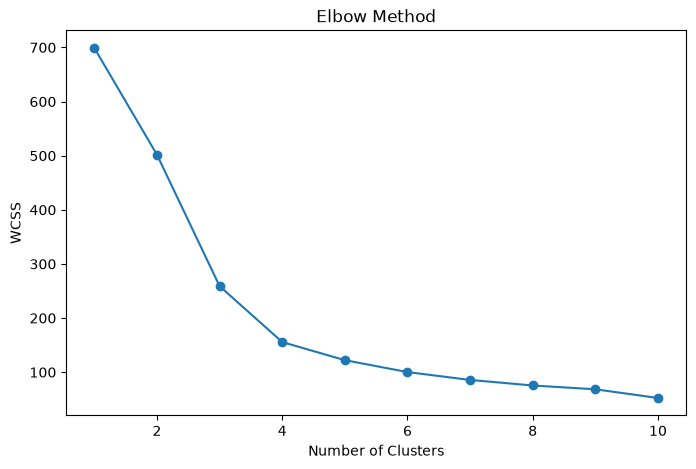

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')

plt.xlabel('Number of Clusters')

plt.ylabel('WCSS')

plt.show()

In [22]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(rfm_scaled)

rfm_features['Cluster'] = clusters

print(rfm_features.head())

                Recency  Frequency      Monetary  Cluster
customer_name                                            
Adam Hart           131         27  4.905845e+63        1
Adrian Barton       190         22  1.427971e+52        0
Alan Shonely         62         20  8.188643e+47        0
Alex Russell          5         20  6.654314e+48        0
Allen Goldenen       65         21  9.310169e+41        0


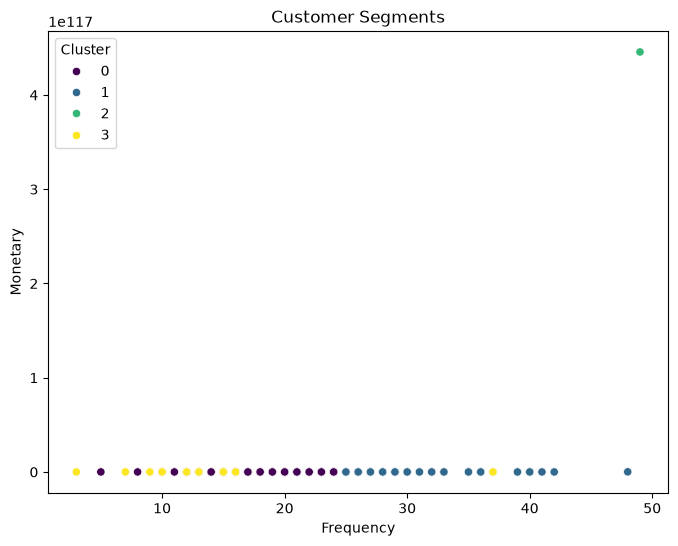

In [23]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=rfm_features['Frequency'],
    y=rfm_features['Monetary'],
    hue=rfm_features['Cluster'],
    palette='viridis'
)

plt.title('Customer Segments')

plt.xlabel('Frequency')

plt.ylabel('Monetary')

plt.show()

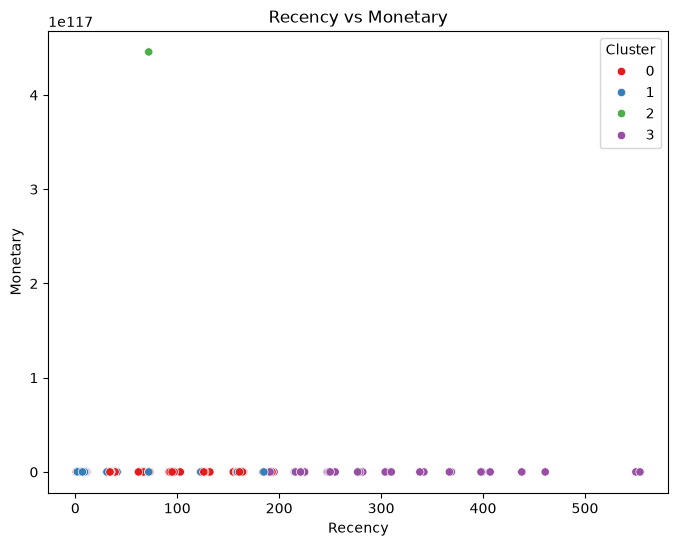

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=rfm_features['Recency'],
    y=rfm_features['Monetary'],
    hue=rfm_features['Cluster'],
    palette='Set1'
)

plt.title('Recency vs Monetary')

plt.xlabel('Recency')

plt.ylabel('Monetary')

plt.show()

In [25]:
cluster_profile = rfm_features.groupby('Cluster').mean()

print(cluster_profile)

            Recency  Frequency       Monetary
Cluster                                      
0         61.275591  18.669291   5.806471e+57
1         42.239437  30.929577  1.537057e+112
2         72.000000  49.000000  4.456785e+117
3        308.411765  15.176471   1.618530e+83


In [26]:
print(rfm_features['Cluster'].value_counts())

Cluster
0    127
1     71
3     34
2      1
Name: count, dtype: int64


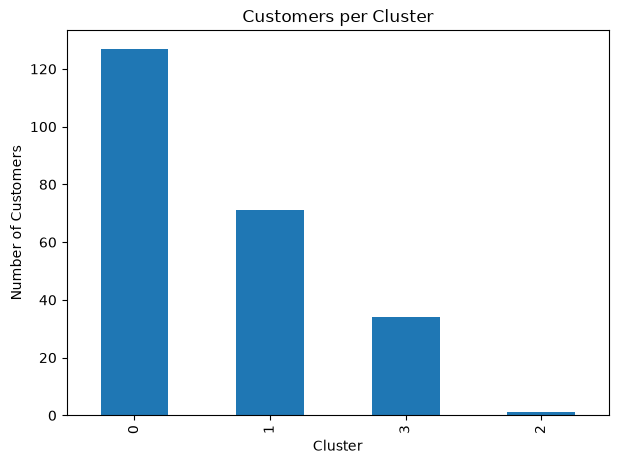

In [27]:
plt.figure(figsize=(7,5))

rfm_features['Cluster'].value_counts().plot(kind='bar')

plt.title('Customers per Cluster')

plt.xlabel('Cluster')

plt.ylabel('Number of Customers')

plt.show()